In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import jax.numpy as jnp
from pydmd import DMD

from examples.plasma_flow import draw_frame, make_plasma, relative_error

plt.style.use("ggplot")

In [2]:
Z, t = make_plasma(nx=96, ny=96, nt=128)
train_sequence = Z[:, :, :96]
pred_idx = train_sequence.shape[2]

In [3]:
snapshots = np.asarray(train_sequence).reshape(train_sequence.shape[0] * train_sequence.shape[1], -1)
rank = 50
model = DMD(svd_rank=rank)
model.fit(snapshots)

modes = np.asarray(model.modes)
eigenvalues = np.asarray(model.eigs)
amplitudes = np.asarray(model.amplitudes)

pred_steps = np.arange(pred_idx + 1)
pred_sequence = []
true_sequence = []
state_errors = []
for step in pred_steps:
    snapshot_pred = modes @ ((eigenvalues**step) * amplitudes)
    snapshot_pred = jnp.asarray(snapshot_pred.reshape(Z.shape[0], Z.shape[1]))
    snapshot_true = Z[:, :, step]
    pred_sequence.append(snapshot_pred)
    true_sequence.append(snapshot_true)
    state_errors.append(relative_error(snapshot_true, snapshot_pred))

pred_sequence = jnp.stack(pred_sequence)
true_sequence = jnp.stack(true_sequence)
state_errors = np.asarray(state_errors)
snapshot_pred = pred_sequence[pred_idx]
snapshot_true = true_sequence[pred_idx]
snapshot_re = float(state_errors[pred_idx])

table = Table(title="Plasma DMD")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("sequence shape", f"{tuple(Z.shape)}")
table.add_row("rank", f"{rank}")
table.add_row("modes shape", f"{tuple(modes.shape)}")
table.add_row("mean state-wise RE", f"{state_errors.mean():.4e}")
table.add_row("max state-wise RE", f"{state_errors.max():.4e}")
table.add_row("snapshot RE", f"{snapshot_re:.4e}")
Console().print(table)

/home/d4y2k/progs/tdmd-toolbox/.venv/lib/python3.14/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 117075216.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


              Plasma DMD              
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Name               ┃ Value         ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence shape     │ (96, 96, 128) │
│ rank               │ 50            │
│ modes shape        │ (9216, 50)    │
│ mean state-wise RE │ 1.6568e-06    │
│ max state-wise RE  │ 3.7436e-06    │
│ snapshot RE        │ 3.6422e-06    │
└────────────────────┴───────────────┘

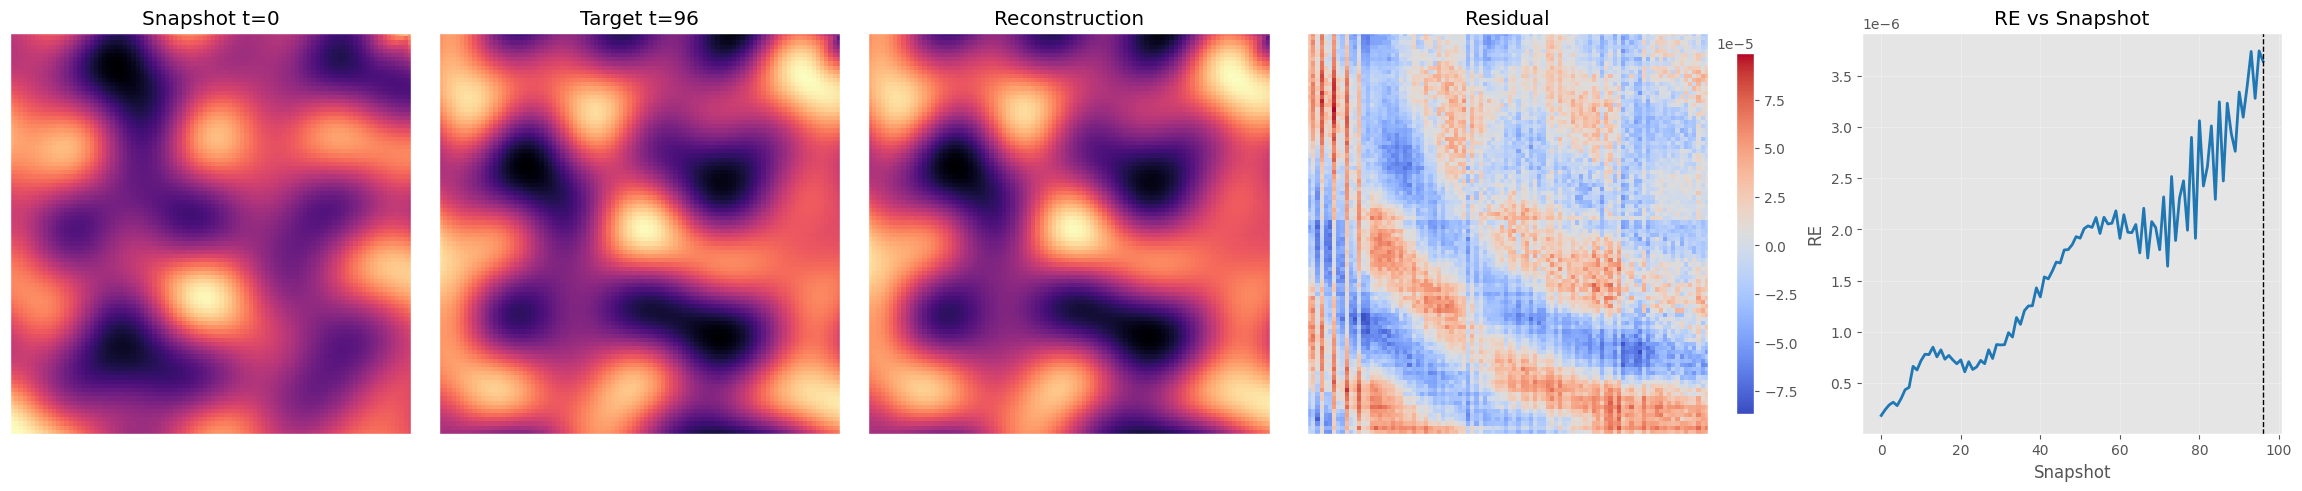

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4.8), constrained_layout=True)

draw_frame(axes[0], Z[:, :, 0], "Snapshot t=0")
draw_frame(axes[1], snapshot_true, f"Target t={pred_idx}")
draw_frame(axes[2], snapshot_pred, "Reconstruction")

residual_img = draw_frame(axes[3], snapshot_true - snapshot_pred, "Residual", cmap="coolwarm")
fig.colorbar(residual_img, ax=axes[3], shrink=0.9, pad=0.02)
axes[4].plot(pred_steps, state_errors, linewidth=2, color="tab:blue")
axes[4].axvline(pred_idx, color="black", linestyle="--", linewidth=1)
axes[4].set_title("RE vs Snapshot")
axes[4].set_xlabel("Snapshot")
axes[4].set_ylabel("RE")
axes[4].grid(True, alpha=0.3)

plt.show();